In [ ]:
import psycopg2
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os
# Configuración de conexión (tu misma)
DB_CONFIG = {
    'host': os.getenv("POSTGRES_HOST"),
    'database': os.getenv("POSTGRES_DB"),
    'user': os.getenv("POSTGRES_USER"),
    'password': os.getenv("POSTGRES_PASSWORD"),
    'port': int(os.getenv("POSTGRES_PORT"))
}

# Conexión
conexion = psycopg2.connect(**DB_CONFIG)

print("Conectado a PostgreSQL")

Conectado a PostgreSQL


## ________________________________________________________________
## **FUNCION PARA DETERMINAR TIEMPOS**

In [3]:
import time

def medir_tiempo(query, nombre):
    try:
        start = time.time()
        df = pd.read_sql(query, conexion)
        end = time.time()

    except Exception as e:
        conexion.rollback()
        start = time.time()
        df = pd.read_sql(query, conexion)
        end = time.time()

    tiempo = end - start
    print(f"{nombre}: {tiempo:.4f} segundos")
    
    return tiempo

## ________________________________________________________________
## **QUERIES SIN INDICE**

In [4]:
query4 = """
SELECT 
    d.driver_id,
    COUNT(del.delivery_id)::numeric / COUNT(DISTINCT t.trip_id) AS avg_deliveries_per_trip
FROM drivers d
JOIN trips t ON d.driver_id = t.driver_id
JOIN deliveries del ON t.trip_id = del.trip_id
WHERE t.departure_datetime >= NOW() - INTERVAL '6 months'
GROUP BY d.driver_id
HAVING COUNT(DISTINCT t.trip_id) > 0
ORDER BY avg_deliveries_per_trip DESC;
"""

tiempo_q4_before = medir_tiempo(query4, "Query 4 BEFORE")

Query 4 BEFORE: 0.1133 segundos


C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_5752\4221030181.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


In [5]:
query6 = """
SELECT 
    d.driver_id,
    d.first_name,
    d.last_name,
    COUNT(del.delivery_id) AS total_deliveries
FROM drivers d
JOIN trips t ON d.driver_id = t.driver_id
JOIN deliveries del ON t.trip_id = del.trip_id
GROUP BY d.driver_id, d.first_name, d.last_name
HAVING COUNT(del.delivery_id) > 1000
ORDER BY total_deliveries DESC;
"""

tiempo_q6_before = medir_tiempo(query6, "Query 6 BEFORE")

Query 6 BEFORE: 0.0862 segundos


C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_5752\4221030181.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


In [6]:
query9 = """
SELECT 
    v.vehicle_type,
    t.trip_id,
    t.total_weight_kg,
    v.capacity_kg,
    (t.total_weight_kg / v.capacity_kg) AS utilization_rate,
    RANK() OVER (
        PARTITION BY v.vehicle_type 
        ORDER BY (t.total_weight_kg / v.capacity_kg) DESC
    ) AS efficiency_rank
FROM trips t
JOIN vehicles v ON t.vehicle_id = v.vehicle_id
WHERE v.capacity_kg > 0;
"""

tiempo_q9_before = medir_tiempo(query9, "Query 9 BEFORE")

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_5752\4221030181.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


Query 9 BEFORE: 0.7666 segundos


In [7]:
query12 = """
SELECT 
    t.trip_id,
    COUNT(CASE WHEN d.delivery_status = 'delivered' THEN 1 END) AS delivered_count,
    COUNT(CASE WHEN d.delivery_status = 'pending' THEN 1 END) AS pending_count,
    COUNT(CASE WHEN d.recipient_signature = TRUE THEN 1 END) AS signed_count
FROM trips t
JOIN deliveries d ON t.trip_id = d.trip_id
GROUP BY t.trip_id
ORDER BY delivered_count DESC;
"""

tiempo_q12_before = medir_tiempo(query12, "Query 12 BEFORE")

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_5752\4221030181.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


Query 12 BEFORE: 0.2720 segundos


## ________________________________________________________________
## **INDICES APLICADOS**

In [ ]:
cursor = conexion.cursor()

indices = [
    "CREATE INDEX idx_trips_vehicle_id ON trips(vehicle_id);",
    "CREATE INDEX idx_trips_driver_id ON trips(driver_id);",
    "CREATE INDEX idx_deliveries_trip_id ON deliveries(trip_id);",
    "CREATE INDEX idx_maintenance_vehicle_id ON maintenance(vehicle_id);",
    "CREATE INDEX idx_trips_route_id ON trips(route_id);"
]

for idx in indices:
    cursor.execute(idx)

conexion.commit()
print("Índices creados correctamente")

## ________________________________________________________________
## **QUERIES CON INDICES**

In [8]:
tiempo_q4_after = medir_tiempo(query4, "Query 4 AFTER")

Query 4 AFTER: 0.0891 segundos


C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_5752\4221030181.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


In [10]:
tiempo_q6_after = medir_tiempo(query6, "Query 6 AFTER")

Query 6 AFTER: 0.1439 segundos


C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_5752\4221030181.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


In [11]:
tiempo_q9_after = medir_tiempo(query9, "Query 9 AFTER")

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_5752\4221030181.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


Query 9 AFTER: 0.7324 segundos


In [12]:
tiempo_q12_after = medir_tiempo(query12, "Query 12 AFTER")

C:\Users\Mi Pc\AppData\Local\Temp\ipykernel_5752\4221030181.py:6: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conexion)


Query 12 AFTER: 0.2630 segundos


## ________________________________________________________________
## **TABLA COMPARATIVA**

In [ ]:
resultados = pd.DataFrame({
    "Query": ["Q4", "Q6", "Q9", "Q12"],
    "Before (s)": [
        tiempo_q4_before,
        tiempo_q6_before,
        tiempo_q9_before,
        tiempo_q12_before],
    "After (s)": [
        tiempo_q4_after,
        tiempo_q6_after,
        tiempo_q9_after,
        tiempo_q12_after]
})
resultados["Mejora (%)"] = ((resultados["Before (s)"] - resultados["After (s)"]) 
    / resultados["Before (s)"]) * 100

resultados

,Query,Before (s),After (s),Mejora (%)
0,Q4,0.113252,0.089122,21.306575
1,Q6,0.086220,0.143923,-66.925585
2,Q9,0.766639,0.732434,4.461706
3,Q12,0.272005,0.263041,3.295549


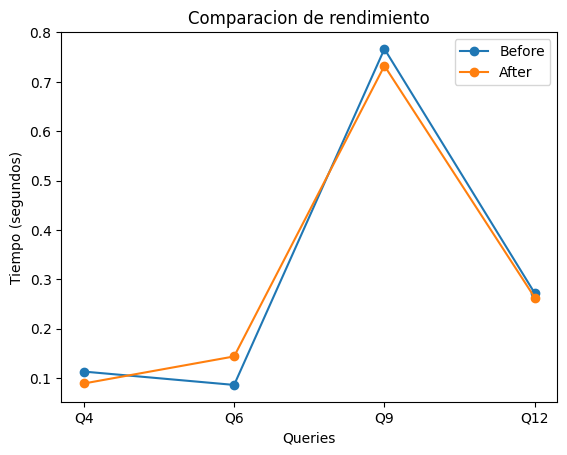

In [ ]:
plt.figure()

plt.plot(resultados["Query"], resultados["Before (s)"], marker='o', label="Before")
plt.plot(resultados["Query"], resultados["After (s)"], marker='o', label="After")

plt.xlabel("Queries")
plt.ylabel("Tiempo (segundos)")
plt.title("Comparacion de rendimiento")
plt.legend()

print("rosa humana tito vete al diablo")
plt.show()